# How did central Plains infrared cloud patterns change over fifteen minutes?

Use GOES-16 channel 13 in mesoscale sector **M1**, 6 May 2024, **22:00–22:15 UTC** (end exclusive). The manifest selects whole scenes; this notebook compares a fixed **34–38°N, 100–96°W** region locally. It answers what changed in observed brightness temperature, without tracking a particular storm or inferring tornado intensity.

**Unreleased:** available from source for v0.25.0 using the [examples setup](https://usdata.dev/examples/#run-examples). Mesoscale support extends `noaa:goes-abi`; the existing CONUS default is unchanged. The committed lockfile pins every scene.

In [1]:
import json
import sys
from datetime import UTC, datetime
from importlib.metadata import version
from pathlib import Path
from tempfile import TemporaryDirectory

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import CRS, Transformer

from usdata import pull, verify

manifest = Path("examples/goes-mesoscale/dataset.yaml")
if not manifest.is_file():
    manifest = Path("dataset.yaml")
print("Executed UTC:", datetime.now(UTC).isoformat(timespec="seconds"))
print("Python:", sys.version.split()[0])
print(
    {name: version(name) for name in ("usdata", "xarray", "h5netcdf", "numpy", "pandas", "pyproj")}
)
result = pull(manifest)
assert verify(manifest) == []
items = sorted(result.fetched, key=lambda item: item.asset.time.start)
assert items and all("CMIPM1-M6C13_G16" in item.asset.id for item in items)
print("Scenes:", len(items), "Source bytes:", sum(item.provenance.size for item in items))
print("Restored committed lockfile:", result.from_lockfile)
print(
    json.dumps(
        [
            {
                "source": item.asset.href,
                "sha256": item.provenance.checksum,
                "retrieved_utc": item.provenance.retrieved_at.isoformat(),
                "bytes": item.provenance.size,
            }
            for item in items
        ],
        indent=2,
    )
)

Executed UTC: 2026-09-22T23:15:00+00:00
Python: 3.14.7
{'usdata': '0.24.0', 'xarray': '2026.7.0', 'h5netcdf': '1.8.1', 'numpy': '2.5.2', 'pandas': '3.0.5', 'pyproj': '3.8.0'}
Scenes: 15 Source bytes: 4925644
Restored committed lockfile: True
[
  {
    "source": "s3://noaa-goes16/ABI-L2-CMIPM/2024/127/22/OR_ABI-L2-CMIPM1-M6C13_G16_s20241272200280_e20241272200349_c20241272200404.nc",
    "sha256": "sha256:4108712cbc4075d1f896c7a08de17a4fde211c6ee33136cac0ab088ddf2c694e",
    "retrieved_utc": "2026-09-22T23:14:57.170416+00:00",
    "bytes": 329131
  },
  {
    "source": "s3://noaa-goes16/ABI-L2-CMIPM/2024/127/22/OR_ABI-L2-CMIPM1-M6C13_G16_s20241272201251_e20241272201320_c20241272201384.nc",
    "sha256": "sha256:f2404f6f9018d32839df52adccca368fa6b54314aa80ba33fdb43918a39c86ef",
    "retrieved_utc": "2026-09-22T23:14:57.319582+00:00",
    "bytes": 329127
  },
  {
    "source": "s3://noaa-goes16/ABI-L2-CMIPM/2024/127/22/OR_ABI-L2-CMIPM1-M6C13_G16_s20241272202251_e20241272202320_c20241272202

## Measure the sampling before comparing images

M1 and M2 share an archive directory. The adapter filters their filenames explicitly. Mesoscale sectors can move between scans, and scan start seconds vary: a minute of coverage does not imply a scan beginning on the minute. Count occupied UTC minute bins and show the actual scan-start intervals; do not insert or interpolate scenes.

In [2]:
starts = pd.DatetimeIndex([item.asset.time.start for item in items])
ends = pd.DatetimeIndex([item.asset.time.end for item in items])
start = pd.Timestamp("2024-05-06T22:00:00Z")
stop = pd.Timestamp("2024-05-06T22:15:00Z")
assert ((starts >= start) & (starts < stop)).all()
assert not starts.duplicated().any(), "Duplicate scan starts need review."
minute_counts = pd.Series(1, index=starts.floor("min")).groupby(level=0).sum()
expected = pd.date_range(start, stop, freq="min", inclusive="left")
missing = expected.difference(minute_counts.index)
print("Missing one-minute bins:", [time.strftime("%H:%M") for time in missing])
print("Scans per occupied minute:", sorted(minute_counts.unique().tolist()))
cadence = pd.DataFrame(
    {
        "start_utc": starts,
        "end_utc": ends,
        "since_previous_seconds": starts.to_series().diff().dt.total_seconds().to_numpy(),
    }
)
cadence

Missing one-minute bins: []
Scans per occupied minute: [1]


,start_utc,end_utc,since_previous_seconds
0,2024-05-06 22:00:28+00:00,2024-05-06 22:00:34.900000+00:00,NaN
1,2024-05-06 22:01:25.100000+00:00,2024-05-06 22:01:32+00:00,57.1
2,2024-05-06 22:02:25.100000+00:00,2024-05-06 22:02:32+00:00,60.0
3,2024-05-06 22:03:25.100000+00:00,2024-05-06 22:03:32.100000+00:00,60.0
4,2024-05-06 22:04:25.100000+00:00,2024-05-06 22:04:32.200000+00:00,60.0
5,2024-05-06 22:05:25.100000+00:00,2024-05-06 22:05:32+00:00,60.0
6,2024-05-06 22:06:25.100000+00:00,2024-05-06 22:06:32+00:00,60.0
7,2024-05-06 22:07:25.100000+00:00,2024-05-06 22:07:32+00:00,60.0
8,2024-05-06 22:08:25.100000+00:00,2024-05-06 22:08:32+00:00,60.0
9,2024-05-06 22:09:25.100000+00:00,2024-05-06 22:09:32.100000+00:00,60.0


## Check the footprint and quality in every file

The local crop is a geographic mask made with the file's geostationary projection. Check each scan's coordinates, projection, and reported extent before reusing that mask; abort if the sector moves. Pixel geolocation here assumes the reference ellipsoid, so elevated clouds can be displaced by parallax.

Accept only finite `CMI` pixels with `DQF == 0`. Channel 13 supplies brightness temperature in **kelvin**, not surface air temperature. Report the 10th percentile and the fraction below **235 K**, an illustrative cold-cloud threshold. These are pixel summaries within a fixed region, not area-weighted statistics or storm-intensity measurements. The accepted-pixel denominator is reported for each scan.

In [3]:
rows, frames, coverage = [], [], []
reference_x = reference_y = reference_projection = reference_extent = None
for item in items:
    with item.open() as scene:
        assert scene.CMI.attrs["units"] == "K" and scene.CMI.dims == ("y", "x")
        assert int(scene.band_id.item()) == 13 and scene.attrs["platform_ID"] == "G16"
        assert pd.Timestamp(scene.attrs["time_coverage_start"]) == pd.Timestamp(
            item.asset.time.start
        )
        assert "good_pixel_qf" in scene.DQF.attrs["flag_meanings"]
        projection = dict(scene.goes_imager_projection.attrs)
        extent = dict(scene.geospatial_lat_lon_extent.attrs)
        if reference_x is None:
            reference_x, reference_y = scene.x.values.copy(), scene.y.values.copy()
            reference_projection, reference_extent = projection, extent
            print("Quality flag values:", scene.DQF.attrs["flag_values"].tolist())
            print("Quality meanings:", scene.DQF.attrs["flag_meanings"])
            transformer = Transformer.from_crs(CRS.from_cf(projection), "EPSG:4326", always_xy=True)
            x, y = np.meshgrid(reference_x, reference_y)
            height = projection["perspective_point_height"]
            lon, lat = transformer.transform(x * height, y * height)
            region = (lon >= -100) & (lon <= -96) & (lat >= 34) & (lat <= 38)
            assert region.any()
            iy, ix = np.where(region)
            ys, xs = slice(iy.min(), iy.max() + 1), slice(ix.min(), ix.max() + 1)
        else:
            assert np.array_equal(scene.x.values, reference_x), "M1 moved: review comparison."
            assert np.array_equal(scene.y.values, reference_y), "M1 moved: review comparison."
            assert projection == reference_projection and extent == reference_extent
        values, flags = scene.CMI.values, scene.DQF.values
        good = region & (flags == 0) & np.isfinite(values)
        accepted = values[good]
        assert accepted.size > 0
        flag_counts = {
            str(int(flag)): int(np.count_nonzero(region & (flags == flag)))
            for flag in np.unique(flags[np.isfinite(flags)])
        }
        rows.append(
            {
                "time": item.asset.time.start,
                "region_pixels": int(region.sum()),
                "accepted_pixels": int(accepted.size),
                "excluded_pixels": int(region.sum() - accepted.size),
                "DQF_counts": flag_counts,
                "missing_DQF": int(np.count_nonzero(region & ~np.isfinite(flags))),
                "p10_K": float(np.quantile(accepted, 0.1)),
                "below_235K_percent": float(100 * np.mean(accepted < 235)),
            }
        )
        coverage.append(
            {
                "time": item.asset.time.start,
                **{
                    key.removeprefix("geospatial_"): float(extent[key])
                    for key in (
                        "geospatial_westbound_longitude",
                        "geospatial_eastbound_longitude",
                        "geospatial_southbound_latitude",
                        "geospatial_northbound_latitude",
                    )
                },
            }
        )
        frames.append(np.where(good, values, np.nan)[ys, xs])
summary = pd.DataFrame(rows).set_index("time")
print("Projection, coordinates, and metadata extent match across all scans.")
print(pd.DataFrame(coverage).to_string(index=False))
summary

Quality flag values: [0, 1, 2, 3, 4]
Quality meanings: good_pixel_qf conditionally_usable_pixel_qf out_of_range_pixel_qf no_value_pixel_qf focal_plane_temperature_threshold_exceeded_qf


Projection, coordinates, and metadata extent match across all scans.
                            time  westbound_longitude  eastbound_longitude  southbound_latitude  northbound_latitude
       2024-05-06 22:00:28+00:00          -110.367836           -91.051788            29.716391            43.402351
2024-05-06 22:01:25.100000+00:00          -110.367836           -91.051788            29.716391            43.402351
2024-05-06 22:02:25.100000+00:00          -110.367836           -91.051788            29.716391            43.402351
2024-05-06 22:03:25.100000+00:00          -110.367836           -91.051788            29.716391            43.402351
2024-05-06 22:04:25.100000+00:00          -110.367836           -91.051788            29.716391            43.402351
2024-05-06 22:05:25.100000+00:00          -110.367836           -91.051788            29.716391            43.402351
2024-05-06 22:06:25.100000+00:00          -110.367836           -91.051788            29.716391            43.40

,region_pixels,accepted_pixels,excluded_pixels,DQF_counts,missing_DQF,p10_K,below_235K_percent
time,,,,,,,
2024-05-06 22:00:28+00:00,23968,23968,0,{'0': 23968},0,220.085388,16.839119
2024-05-06 22:01:25.100000+00:00,23968,23968,0,{'0': 23968},0,219.962494,16.905874
2024-05-06 22:02:25.100000+00:00,23968,23968,0,{'0': 23968},0,219.716675,16.997664
2024-05-06 22:03:25.100000+00:00,23968,23968,0,{'0': 23968},0,219.593781,17.072764
2024-05-06 22:04:25.100000+00:00,23968,23968,0,{'0': 23968},0,219.532318,17.135347
2024-05-06 22:05:25.100000+00:00,23968,23968,0,{'0': 23968},0,219.347961,17.289720
2024-05-06 22:06:25.100000+00:00,23968,23968,0,{'0': 23968},0,219.286499,17.394025
2024-05-06 22:07:25.100000+00:00,23968,23968,0,{'0': 23968},0,219.225067,17.544226
2024-05-06 22:08:25.100000+00:00,23968,23968,0,{'0': 23968},0,219.102142,17.698598


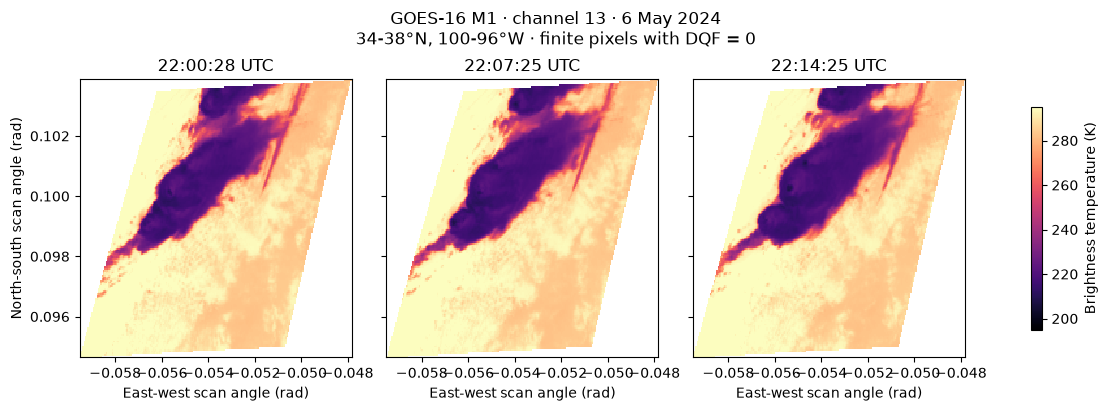

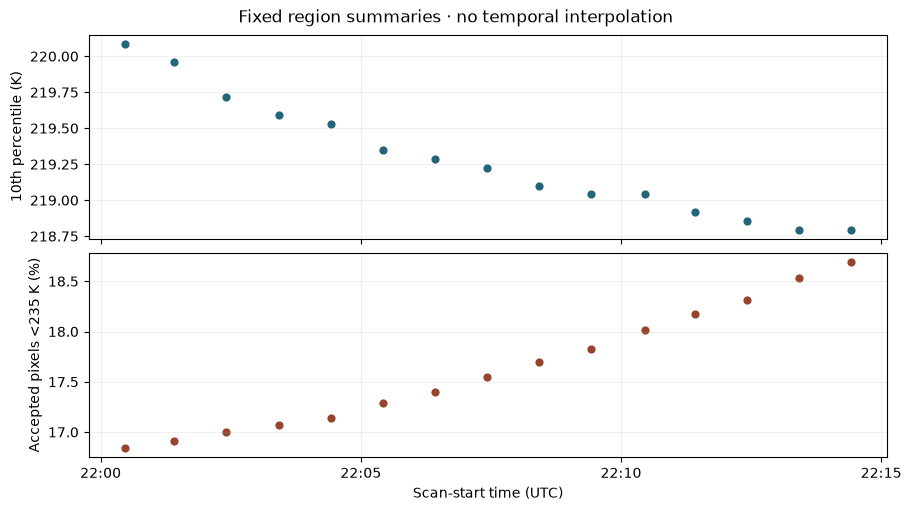

10th percentile: 220.09 → 218.79 K
Cold-pixel fraction: 16.84 → 18.69%


In [4]:
selected = sorted(set([0, len(items) // 2, len(items) - 1]))
fig, axes = plt.subplots(
    1,
    len(selected),
    figsize=(11, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    squeeze=False,
)
for axis, index in zip(axes[0], selected, strict=True):
    mesh = axis.pcolormesh(
        reference_x[xs],
        reference_y[ys],
        frames[index],
        shading="auto",
        cmap="magma",
        vmin=195,
        vmax=295,
    )
    axis.set_title(f"{items[index].asset.time.start:%H:%M:%S} UTC")
    axis.set_xlabel("East-west scan angle (rad)")
axes[0, 0].set_ylabel("North-south scan angle (rad)")
fig.colorbar(mesh, ax=axes.ravel().tolist(), label="Brightness temperature (K)", shrink=0.8)
fig.suptitle("GOES-16 M1 · channel 13 · 6 May 2024\n34-38°N, 100-96°W · finite pixels with DQF = 0")
plt.show()
plt.close(fig)

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True, constrained_layout=True)
# Scatter points preserve irregular sampling and do not bridge absent scans.
axes[0].scatter(summary.index, summary.p10_K, color="#23657b", s=24)
axes[0].set_ylabel("10th percentile (K)")
axes[1].scatter(summary.index, summary.below_235K_percent, color="#98442c", s=24)
axes[1].set_ylabel("Accepted pixels <235 K (%)")
axes[1].set_xlabel("Scan-start time (UTC)")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz=UTC))
for axis in axes:
    axis.grid(alpha=0.2)
    for time in missing:
        axis.axvspan(time, time + pd.Timedelta(minutes=1), color="gray", alpha=0.2)
fig.suptitle("Fixed region summaries · no temporal interpolation")
plt.show()
plt.close(fig)
print(f"10th percentile: {summary.p10_K.iloc[0]:.2f} → {summary.p10_K.iloc[-1]:.2f} K")
print(
    f"Cold-pixel fraction: {summary.below_235K_percent.iloc[0]:.2f} → "
    f"{summary.below_235K_percent.iloc[-1]:.2f}%"
)

## Restore the exact inputs

The figures describe this fixed region and window. Cloud movement into or out of the region, growth, and changing valid-pixel coverage can all alter the summaries. This example does not distinguish those mechanisms. Raw NetCDF files remain unchanged; the lockfile records URLs, retrieval times, sizes, and checksums for citation and later restoration.

In [5]:
assert verify(manifest) == []
original = {item.asset.id: item for item in items}
with TemporaryDirectory(prefix="usdata-mesoscale-restore-") as fresh:
    restored = pull(manifest, root=fresh)
    assert restored.from_lockfile and not any(item.from_cache for item in restored.fetched)
    assert restored.lockfile == result.lockfile
    assert {item.asset.id for item in restored.fetched} == set(original)
    assert verify(manifest, root=fresh) == []
    for item in restored.fetched:
        assert item.path.read_bytes() == original[item.asset.id].path.read_bytes()
print(f"All {len(items)} pinned scenes restored byte-for-byte into an empty cache.")
print(
    "Citation: NOAA GOES-16 ABI L2 Cloud and Moisture Imagery, M1, C13, "
    "2024-05-06 22:00-22:15 UTC; source URLs and retrieval dates are recorded above "
    "and checksums are pinned in dataset.lock.json."
)

All 15 pinned scenes restored byte-for-byte into an empty cache.
Citation: NOAA GOES-16 ABI L2 Cloud and Moisture Imagery, M1, C13, 2024-05-06 22:00-22:15 UTC; source URLs and retrieval dates are recorded above and checksums are pinned in dataset.lock.json.
